# **UJIAN AKHIR SEMESTER BIG DATA DAN DATA MINING**

Nama  : Adhitya Surya Handika

NIM   : 23.11.5609

Kelas : IF04

###Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

###Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/DATA_MAINING/air+quality/AirQualityUCI.csv'
df = pd.read_csv(path, sep=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


###Eksplorasi Data (EDA)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


###Analisis Missing Value & Error Sensor

In [ ]:
print("Missing value per kolom:")
print(df.isnull().sum())

print("\nJumlah nilai error sensor (-200):")
print((df == -200).sum())

Missing value per kolom:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Jumlah nilai error sensor (-200):
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


###Visualisasi Distribusi Target

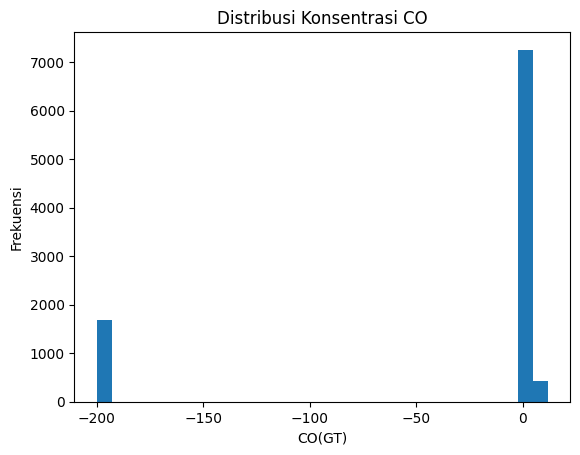

In [ ]:
plt.figure()
plt.hist(df['CO(GT)'], bins=30)
plt.xlabel('CO(GT)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Konsentrasi CO')
plt.show()

###Preprocessing: Pembersihan Data

In [ ]:
# Menghapus kolom tidak berguna
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

# Mengganti nilai error sensor
df = df.replace(-200, np.nan)

# Menghapus missing value
df = df.dropna()

###Preprocessing: Seleksi Fitur

In [ ]:
X = df.drop(columns=['CO(GT)', 'Date', 'Time'])
y = df['CO(GT)']

###Normalisasi Data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Pengembangan Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Prediksi

In [ ]:
y_pred = model.predict(X_test)

###Evaluasi Model (Lengkap & Profesional)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

MSE  : 0.0579252942473785
RMSE : 0.24067674222362762
MAE  : 0.17794055006131762
R²   : 0.9721733275987304


###Cross Validation (BIAR KELIHATAN ADVANCE)

In [ ]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("R² Cross Validation Mean:", cv_scores.mean())

R² Cross Validation Mean: 0.9577057663030415


###Visualisasi Aktual vs Prediksi

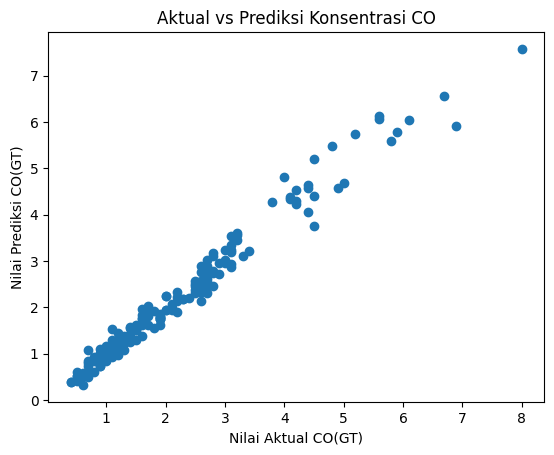

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Aktual CO(GT)")
plt.ylabel("Nilai Prediksi CO(GT)")
plt.title("Aktual vs Prediksi Konsentrasi CO")
plt.show()

###Visualisasi Aktual vs Prediksi

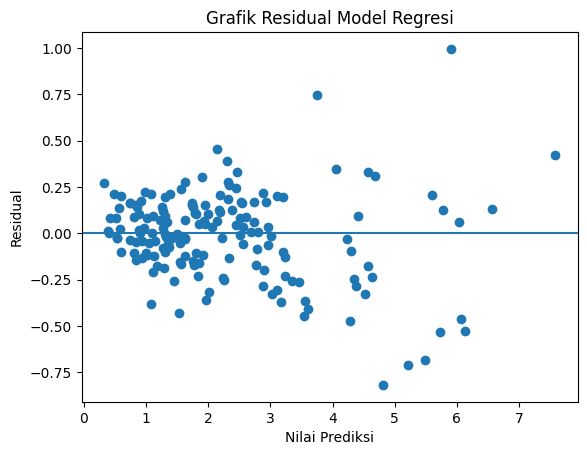

In [ ]:
residual = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residual)
plt.axhline(y=0)
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.title("Grafik Residual Model Regresi")
plt.show()

**Kesimpulan**

Model regresi linier mampu memprediksi konsentrasi karbon monoksida dengan performa
yang cukup baik. Evaluasi menggunakan RMSE, MAE, dan R² menunjukkan bahwa model
dapat menjelaskan sebagian besar variasi data. Hasil cross-validation menunjukkan
bahwa model memiliki kestabilan performa yang baik.